# Simulating Expected Nonlinearity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy
import pandas as pd

import matplotlib
matplotlib.rcParams.update(
    {
        'text.usetex': True,
        "font.family": "serif",
        "font.size": 30,
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,
    }
)
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{mathrsfs}')

In [4]:
# numpy functions
def f1(x, beta):
    return np.sign(x)*np.power(np.abs(x), beta)

def f2(x, beta):
    scale = np.abs((x + 1) * 0.5)
    return np.power(scale, beta) / 0.5 - 1

def f3(x, beta):
    scale = np.abs((x - 1) / 2)
    return -np.power(np.abs(scale), beta) / 0.5 + 1

# sympy functions
def f1_(x, beta):
    return sympy.sign(x) * sympy.Abs(x)**beta

def f2_(x, beta):
    return 2* sympy.Abs((x+1)/2)**beta -1

def f3_(x, beta):
    return -2*sympy.Abs(-(x-1)/2)**beta +1



def calc_optimal_ab_sympy(f, beta):
    x = sympy.Symbol("x", real=True)

    a = float(3/2*sympy.integrate(x*f(x, beta), (x, -1, 1)))
    b = float(1/2*sympy.integrate(f(x, beta), (x, -1, 1)))

    return a,b


# sympy has problems with rationals, hence we also implement an alternative using 
# the numpy functions
# Example for problem: calc_optimal_ab_sympy(f3_, 0.5)
def calc_optimal_ab_numpy(f, beta, accuracy=1000):
    xs = np.linspace(-1, 1, accuracy, endpoint=True)
    dx = -(xs[0]-xs[1])

    evals = [f(x, beta) for x in xs]
    a = (3/2) * np.sum([x*fx*dx for x, fx in zip(xs,evals)])
    b = 1/2 * np.sum([fx*dx for fx in evals])

    return a,b



def calc_optimal_ab(f_num, beta, accuracy=1000):
    sympy_funs = [f1_, f2_, f3_]
    numpy_funs = [f1, f2, f3]

    try:
        a,b = calc_optimal_ab_sympy(sympy_funs[f_num-1], beta)
    except (ValueError, TypeError) as e:
        a,b = calc_optimal_ab_numpy(numpy_funs[f_num-1], beta, accuracy=accuracy)

    return a,b

In [5]:
def linear(x,a,b):
    return a*x + b

In [6]:
def get_intervals(level):
    # low = (2**(-level-1), 2**(-level))
    # high =  (2**level, 2**(level+1))

    # new def
    levels = {
        1: ((1/2, 1), (1, 2)),
        2: ((1/4, 1/2), (2, 4)),
        3: ((1/8, 1/4), (4, 8)),
        4: ((1/12, 1/8), (8, 12)),
        5: ((1/20, 1/12), (12,20)),        
    }
    return levels[level]

In [7]:
def sample_beta_from_level(level):
    intervals =  get_intervals(level)
    idx = np.random.randint(0,2)

    interval = intervals[idx]
    beta = np.random.uniform(interval[0], interval[1])
    return beta


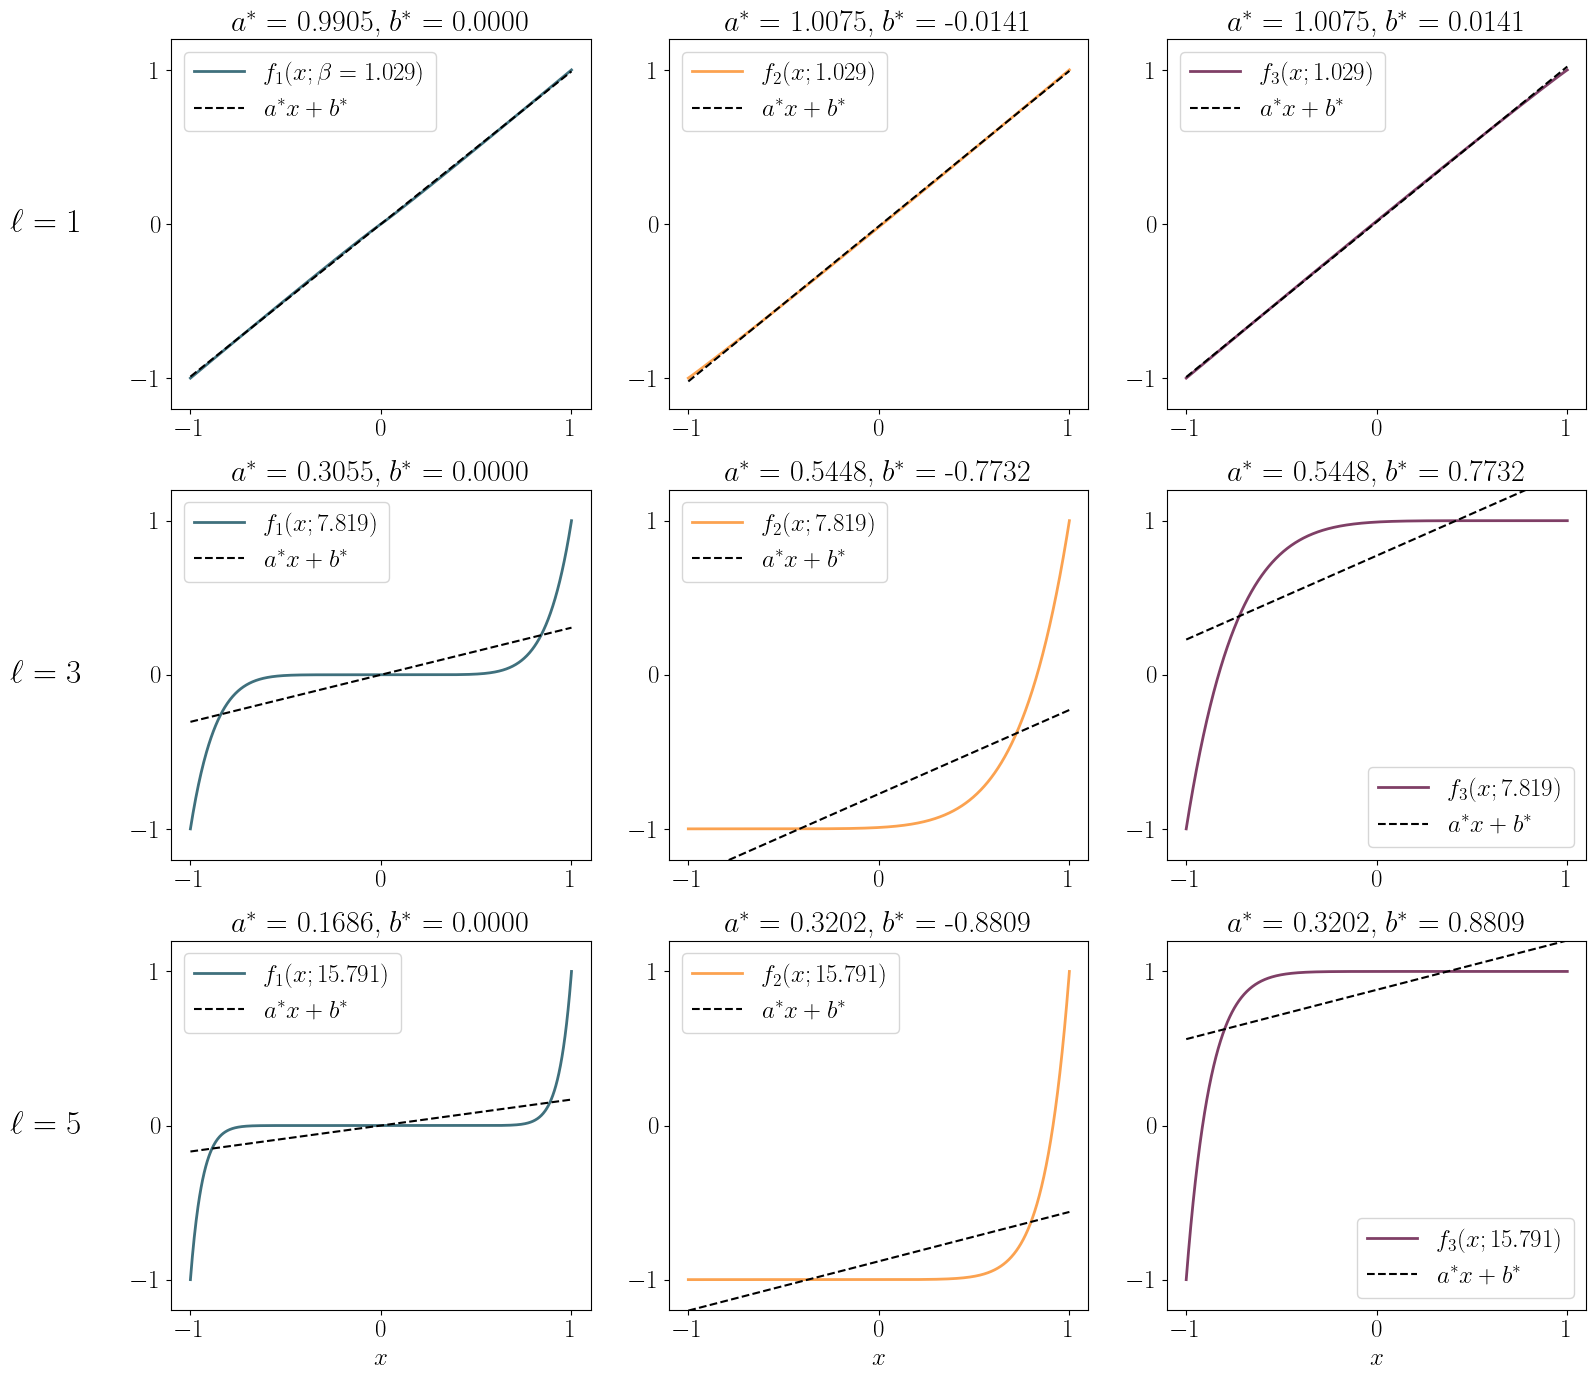

In [ ]:
matplotlib.rcParams.update(
    {
        "font.size": 18,
    }
)

ylims = (-1.2, 1.2)
ell_size=24
ell_dist = -0.3

xs = np.linspace(-1, 1, 1000, endpoint=True)
fig = plt.figure(figsize=(16,14))

beta = sample_beta_from_level(1)

ax = fig.add_subplot(331)
ax.plot(xs, [f1(x,beta) for x in xs], label=rf"$f_1(x; \beta={beta:.3f})$", linewidth=2, c="#0f4c5c", alpha=0.8)
a,b = calc_optimal_ab(1, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()
ax.set_ylabel("$\ell=1\quad$   ", rotation=0, fontdict={"size": ell_size}, ha='center', va='center')
ax.yaxis.set_label_coords(ell_dist, 0.5)

ax = fig.add_subplot(332)
ax.plot(xs, [f2(x,beta) for x in xs], label=rf"$f_2(x; {beta:.3f})$", linewidth=2, c="#fb8b24", alpha=0.8)
a,b = calc_optimal_ab(2, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()

ax = fig.add_subplot(333)
ax.plot(xs, [f3(x,beta) for x in xs], label=rf"$f_3(x; {beta:.3f})$", linewidth=2, c="#5f0f40", alpha=0.8)
a,b = calc_optimal_ab(3, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()


beta = sample_beta_from_level(3)

ax = fig.add_subplot(334)
ax.plot(xs, [f1(x,beta) for x in xs], label=rf"$f_1(x; {beta:.3f})$", linewidth=2, c="#0f4c5c", alpha=0.8)
a,b = calc_optimal_ab(1, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()
ax.set_ylabel("$\ell=3\quad$   ", rotation=0, fontdict={"size": ell_size}, ha='center', va='center')
ax.yaxis.set_label_coords(ell_dist, 0.5)

ax = fig.add_subplot(335)
ax.plot(xs, [f2(x,beta) for x in xs], label=rf"$f_2(x; {beta:.3f})$", linewidth=2, c="#fb8b24", alpha=0.8)
a,b = calc_optimal_ab(2, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()

ax = fig.add_subplot(336)
ax.plot(xs, [f3(x,beta) for x in xs], label=rf"$f_3(x; {beta:.3f})$", linewidth=2, c="#5f0f40", alpha=0.8)
a,b = calc_optimal_ab(3, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()


beta = sample_beta_from_level(5)

ax = fig.add_subplot(337)
ax.plot(xs, [f1(x,beta) for x in xs], label=rf"$f_1(x; {beta:.3f})$", linewidth=2, c="#0f4c5c", alpha=0.8)
a,b = calc_optimal_ab(1, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()
ax.set_xlabel("$x$")
ax.set_ylabel("$\ell=5\quad$   ", rotation=0, fontdict={"size": ell_size}, ha='center', va='center')
ax.yaxis.set_label_coords(ell_dist, 0.5)

ax = fig.add_subplot(338)
ax.plot(xs, [f2(x,beta) for x in xs], label=rf"$f_2(x; {beta:.3f})$", linewidth=2, c="#fb8b24", alpha=0.8)
a,b = calc_optimal_ab(2, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()
ax.set_xlabel("$x$")

ax = fig.add_subplot(339)
ax.plot(xs, [f3(x,beta) for x in xs], label=rf"$f_3(x; {beta:.3f})$", linewidth=2, c="#5f0f40", alpha=0.8)
a,b = calc_optimal_ab(3, beta)
ax.plot(xs, [linear(x,a,b) for x in xs], c="black", linestyle="--", label="$a^*x + b^*$")
ax.set_title(f"$a^*$ = {a:.4f}, $b^*$ = {b:.4f}")
ax.set_ylim(*ylims)
ax.legend()
ax.set_xlabel("$x$")

#_ = fig.suptitle(r"$\beta = $" + str(beta))
fig.tight_layout(pad=0.8)

fig.savefig("../img/powerfam_bestFit_examples.pdf")


matplotlib.rcParams.update(
    {
        "font.size": 30,
    }
)

In [9]:
def compute_min_mse(f_num, beta, accuracy=1000):
    numpy_funs = [f1, f2, f3]
    
    f = numpy_funs[f_num-1]
    a,b = calc_optimal_ab(f_num, beta, accuracy=accuracy)

    xs = np.linspace(-1,1, accuracy, endpoint=True)
    fx = np.array([f(x, beta) for x in xs])
    lx = np.array([linear(x, a, b) for x in xs])

    mse = np.mean((fx-lx)**2)
    return mse

In [11]:
simulated_expected_mses = {
    "level": [1, 2, 3, 4, 5],
    "f1": [],
    "f2": [],
    "f3": [],
    "overall": []
}

num_beta_samples = 1000

for level in simulated_expected_mses["level"]:
    print(f"Beta Level {level}")
    for f_num in range(1,4):
        mses = [compute_min_mse(f_num, sample_beta_from_level(level), accuracy=10000) for _ in range(num_beta_samples)]

        simulated_expected_mses[f"f{f_num}"].append(np.mean(mses))

    simulated_expected_mses["overall"].append(
        (simulated_expected_mses["f1"][-1]+simulated_expected_mses["f2"][-1]+simulated_expected_mses["f3"][-1])/3
    )

simulated_expected_mses

Beta Level 1
Beta Level 2
Beta Level 3
Beta Level 4
Beta Level 5


{'level': [1, 2, 3, 4, 5],
 'f1': [np.float64(0.005684205978439999),
  np.float64(0.03155590433295933),
  np.float64(0.06696841499146336),
  np.float64(0.09109562757242083),
  np.float64(0.09876277669154716)],
 'f2': [np.float64(0.005772047936172786),
  np.float64(0.031351685387912095),
  np.float64(0.04797995919140436),
  np.float64(0.04760562884113526),
  np.float64(0.03653872554975604)],
 'f3': [np.float64(0.0056765035117439236),
  np.float64(0.02981067109485545),
  np.float64(0.047852824491794364),
  np.float64(0.04622595959469978),
  np.float64(0.039828923525213056)],
 'overall': [np.float64(0.005710919142118903),
  np.float64(0.03090608693857563),
  np.float64(0.05426706622488736),
  np.float64(0.06164240533608529),
  np.float64(0.05837680858883876)]}

In [ ]:
df = pd.DataFrame.from_dict(simulated_expected_mses)
print(df)

print(df.to_latex(index=False))

In [ ]:
betas = np.linspace(0.01, 100, 10000)

Df1 = [compute_min_mse(1, beta) for beta in betas]
Df2 = [compute_min_mse(2, beta) for beta in betas]
Df3 = [compute_min_mse(3, beta) for beta in betas]

100%|██████████| 10000/10000 [1:51:56<00:00,  1.49it/s]


[0.0038778578540658542, 0.003930484164624229, 0.004112779625517492, 0.004398616152234085, 0.0047653874929029175, 0.00519359153877584, 0.005666460302270145, 0.006169632148735357, 0.0066908614879440855, 0.007219761679295592, 0.007747577389299791, 0.008266983068513447, 0.00877190459428098, 0.00925736146116442, 0.00971932719792299, 0.010154605952811863, 0.010560723421772545, 0.010935830500277953, 0.011278618222256096, 0.011588242711368803, 0.011864259013367923, 0.012106562805411749, 0.012315339090972816, 0.012491017088958552, 0.012634230614361594, 0.012745783326448396, 0.01282661829032578, 0.012877791359705003, 0.012900447943705397, 0.012895802769394313, 0.012865122295146858, 0.012809709468445863, 0.012730890555977894, 0.012630003804299883, 0.012508389716382615, 0.012367382753362417, 0.012208304292188405, 0.01203245668883813, 0.011841118313654728, 0.011635539440368277, 0.01141693888371189, 0.011186501292413642, 0.010945375014902853, 0.010694670464459394, 0.010435458918886548, 0.01016877169

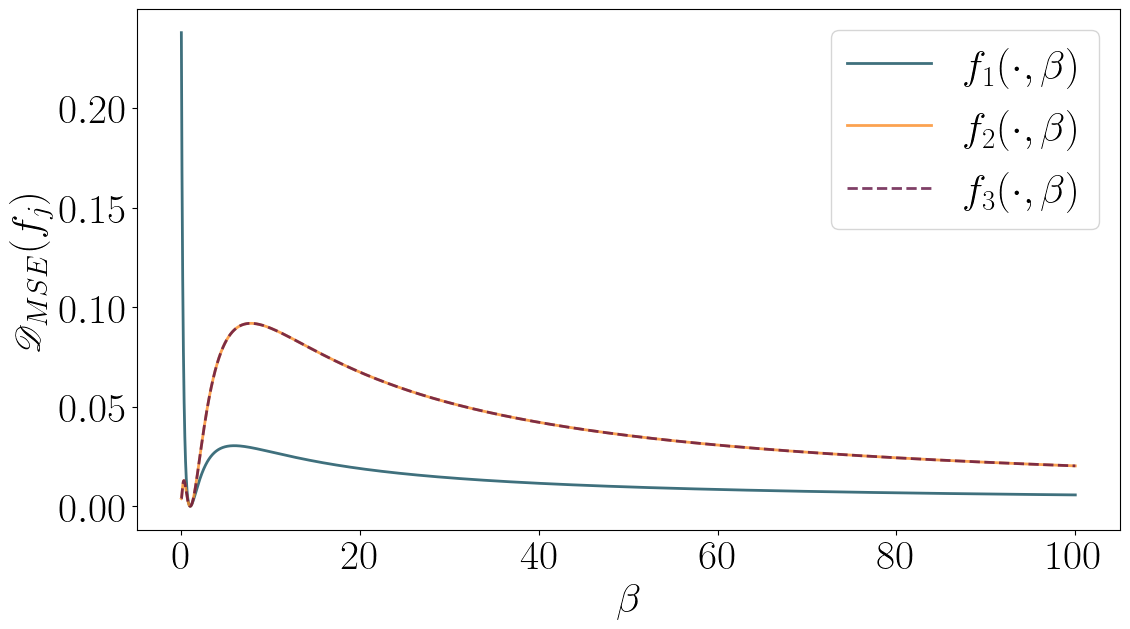

In [ ]:
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111)

print(Df2)

ax.plot(betas, Df1, label=r"$f_1(\cdot, \beta)$", ls="-", alpha=0.8, c="#0f4c5c", linewidth=2)
ax.plot(betas, Df2, label=r"$f_2(\cdot, \beta)$", ls="-", alpha=0.8, c="#fb8b24", linewidth=2)
ax.plot(betas, Df3, label=r"$f_3(\cdot, \beta)$", ls="--", alpha=0.8, c="#5f0f40", linewidth=2)

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\mathscr{D}_{MSE}(f_j)$")

ax.legend()
fig.tight_layout()
fig.savefig("../simulated_D-mse_powerfam.pdf")

## Now for the b splines

In [87]:
from scipy.interpolate import make_interp_spline

In [108]:
def calc_optimal_ab_spline(f, accuracy=1000):
    xs = np.linspace(-1, 1, accuracy, endpoint=True)
    dx = -(xs[0]-xs[1])

    evals = [f(x) for x in xs]
    a = (3/2) * np.sum([x*fx*dx for x, fx in zip(xs,evals)])
    b = 1/2 * np.sum([fx*dx for fx in evals])

    return a,b


def sample_spline_num_samples(num_samples):
    x_range = (-1, 1)
    x_nodes = np.linspace(x_range[0], x_range[1], num_samples)

    y_nodes = np.zeros_like(x_nodes)
    y_nodes[0] = np.random.uniform(0, 1)
    for i in range(1, len(y_nodes)):
        y_nodes[i] = y_nodes[i - 1] + np.random.uniform(0, 10)
    y_nodes = (
        2
        * (y_nodes - np.min(y_nodes))
        / (np.max(y_nodes) - np.min(y_nodes))
        - 1
    )

    b = make_interp_spline(x_nodes, y_nodes, k=3)
    return b

def sample_spline_from_level(level):
    spline_levels = [25, 15, 10, 6, 4]
    return sample_spline_num_samples(spline_levels[level-1])



def compute_min_mse_spline(f, accuracy=1000):
    a,b = calc_optimal_ab_spline(f, accuracy=accuracy)

    xs = np.linspace(-1,1, accuracy, endpoint=True)
    fx = np.array([f(x) for x in xs])
    lx = np.array([linear(x, a, b) for x in xs])

    mse = np.mean((fx-lx)**2)
    return mse

In [ ]:
simulated_expected_mses_splines = {
    "level": [1, 2, 3, 4, 5],
    "Exp. Nonlin": []
}

num_samples_per_level = 10000

for level in simulated_expected_mses_splines["level"]:
    print(f"Spline Level {level}")
    mses = [compute_min_mse_spline(sample_spline_from_level(level), accuracy=1000) for _ in tqdm(range(num_samples_per_level))]
    simulated_expected_mses_splines["Exp. Nonlin"].append(np.mean(mses))


df = pd.DataFrame.from_dict(simulated_expected_mses_splines)
print(df)

print(df.to_latex(index=False))

In [126]:
simulated_expected_mses_splines = {
    "num": list(range(4,51)),
    "mean": [],
    "std": []
}

num_samples_per_level = 1000
for level in simulated_expected_mses_splines["num"]:
    print(f"Num Samples {level}")
    mses = [compute_min_mse_spline(sample_spline_num_samples(level), accuracy=1000) for _ in range(num_samples_per_level)]

    simulated_expected_mses_splines["mean"].append(np.mean(mses))
    simulated_expected_mses_splines["std"].append(np.std(mses))


simulated_expected_mses_splines

Num Samples 4
Num Samples 5
Num Samples 6
Num Samples 7
Num Samples 8
Num Samples 9
Num Samples 10
Num Samples 11
Num Samples 12
Num Samples 13
Num Samples 14
Num Samples 15
Num Samples 16
Num Samples 17
Num Samples 18
Num Samples 19
Num Samples 20
Num Samples 21
Num Samples 22
Num Samples 23
Num Samples 24
Num Samples 25
Num Samples 26
Num Samples 27
Num Samples 28
Num Samples 29
Num Samples 30
Num Samples 31
Num Samples 32
Num Samples 33
Num Samples 34
Num Samples 35
Num Samples 36
Num Samples 37
Num Samples 38
Num Samples 39
Num Samples 40
Num Samples 41
Num Samples 42
Num Samples 43
Num Samples 44
Num Samples 45
Num Samples 46
Num Samples 47
Num Samples 48
Num Samples 49
Num Samples 50


{'num': [4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50],
 'mean': [0.01926830367638538,
  0.020766890348284134,
  0.017589371624999017,
  0.01536732993120641,
  0.012963568913941043,
  0.011687937218582916,
  0.009920474882148944,
  0.00932895322658709,
  0.008494864874351027,
  0.0073456602408388675,
  0.0069335730066887175,
  0.006599432871166421,
  0.006279897644911763,
  0.005424702059119765,
  0.005219716648850624,
  0.005055417478039457,
  0.004710863198579957,
  0.004602693784427942,
  0.004333392032743086,
  0.004188738940621244,
  0.003875432069835594,
  0.0037145566740297217,
  0.0035933604933118444,
  0.003438522469671457,
  0.003365775886294351,
  0.0033107952834307056,
  0.003208872526790741,
  0.0030341004858380574,
  0.002989372537944974,
  0.00282

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


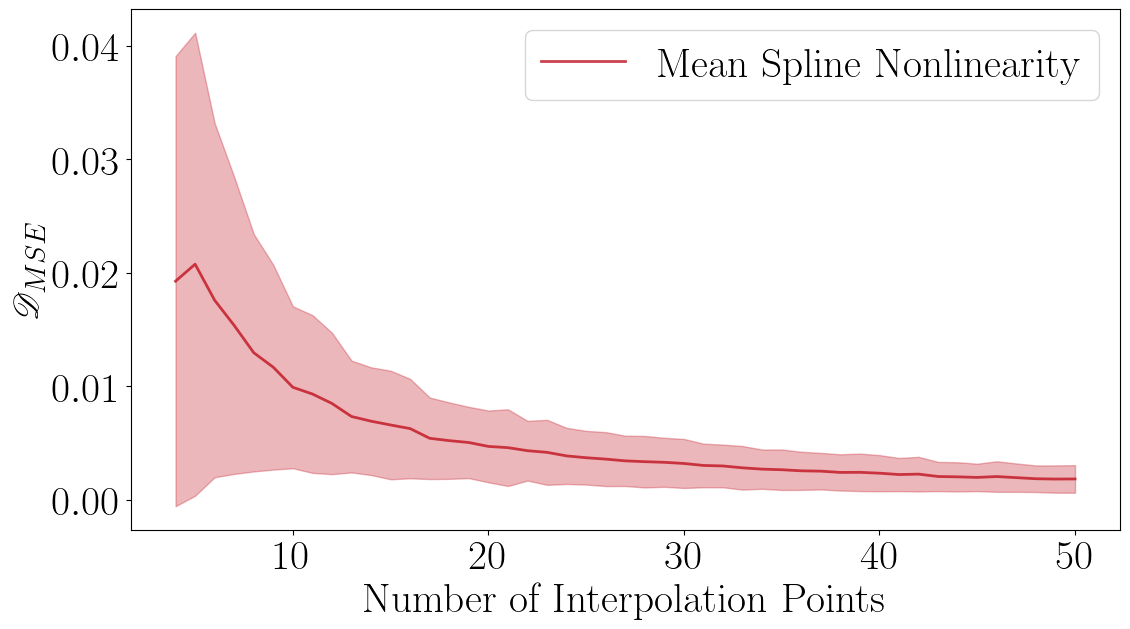

In [127]:
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111)

print(simulated_expected_mses_splines["num"])

ax.plot(simulated_expected_mses_splines["num"], simulated_expected_mses_splines["mean"], 
        label="Mean Spline Nonlinearity", ls="-", alpha=0.8, c="#c1121f", linewidth=2)

yerr0 = np.array(simulated_expected_mses_splines["mean"]) - np.array(simulated_expected_mses_splines["std"])
yerr1 = np.array(simulated_expected_mses_splines["mean"]) + np.array(simulated_expected_mses_splines["std"])
ax.fill_between(simulated_expected_mses_splines["num"], yerr0, yerr1, color='#c1121f', alpha=0.3)

ax.set_xlabel("Number of Interpolation Points")
ax.set_ylabel(r"$\mathscr{D}_{MSE}$")

ax.legend()
fig.tight_layout()
fig.savefig("simulated_D-mse_splines.pdf")

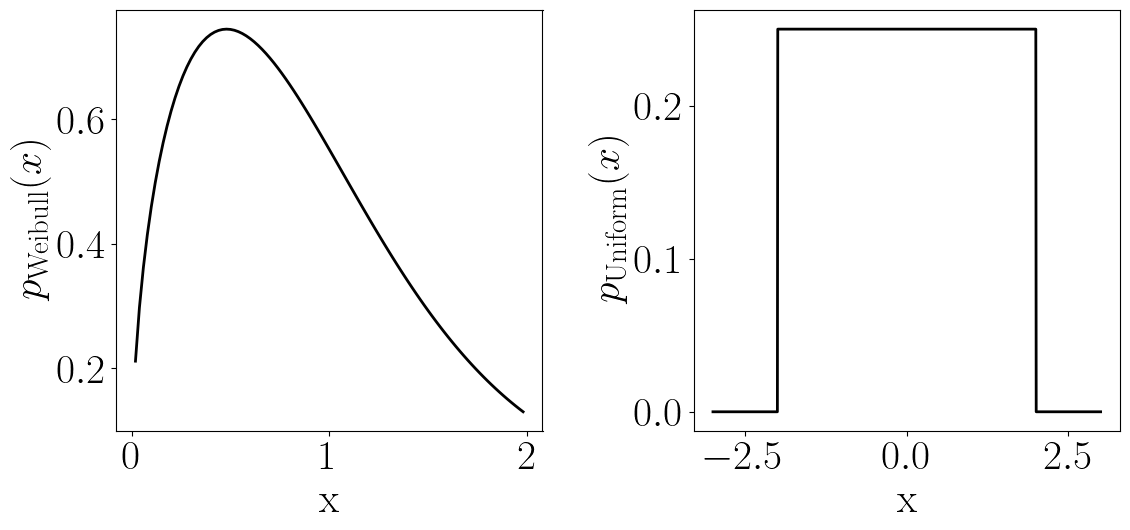

In [2]:
a = 1.5 # shape

s = np.random.weibull(a, 1000)

def weib(x,n,a):
    return (a / n) * (x / n)**(a - 1) * np.exp(-(x / n)**a)

x = np.arange(1,100.)/50.


fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(121)

ax.plot(x, weib(x, 1., a), c="black", linewidth=2)
ax.set_xlabel("x")
ax.set_ylabel(r"$p_{\mathrm{Weibull}}(x)$")


ax = fig.add_subplot(122)
def uniform(x, a,b):
    tmp = x.copy()

    tmp[x < a] = 0
    tmp[x > b] = 0
    tmp[np.logical_and(a <= x, x <= b)] = 1/(b-a)
    return tmp

x = np.linspace(-3,3,1000, endpoint=True)
ax.plot(x, uniform(x, -2, 2), c="black", linewidth=2)
ax.set_xlabel("x")
ax.set_ylabel(r"$p_{\mathrm{Uniform}}(x)$")



fig.tight_layout()
fig.savefig("../img/weib+uniform_samples.pdf")